## Gaussian Mixture

In [36]:
import numpy as np
from matplotlib import pyplot as plt
if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=True)
from sklearn.mixture import GaussianMixture
from scipy.stats import norm
from scipy.stats import multivariate_normal

bin_counts = 100
N_components = 10

Load the data and plot them as histogram.

Text(0, 0.5, 'PDF')

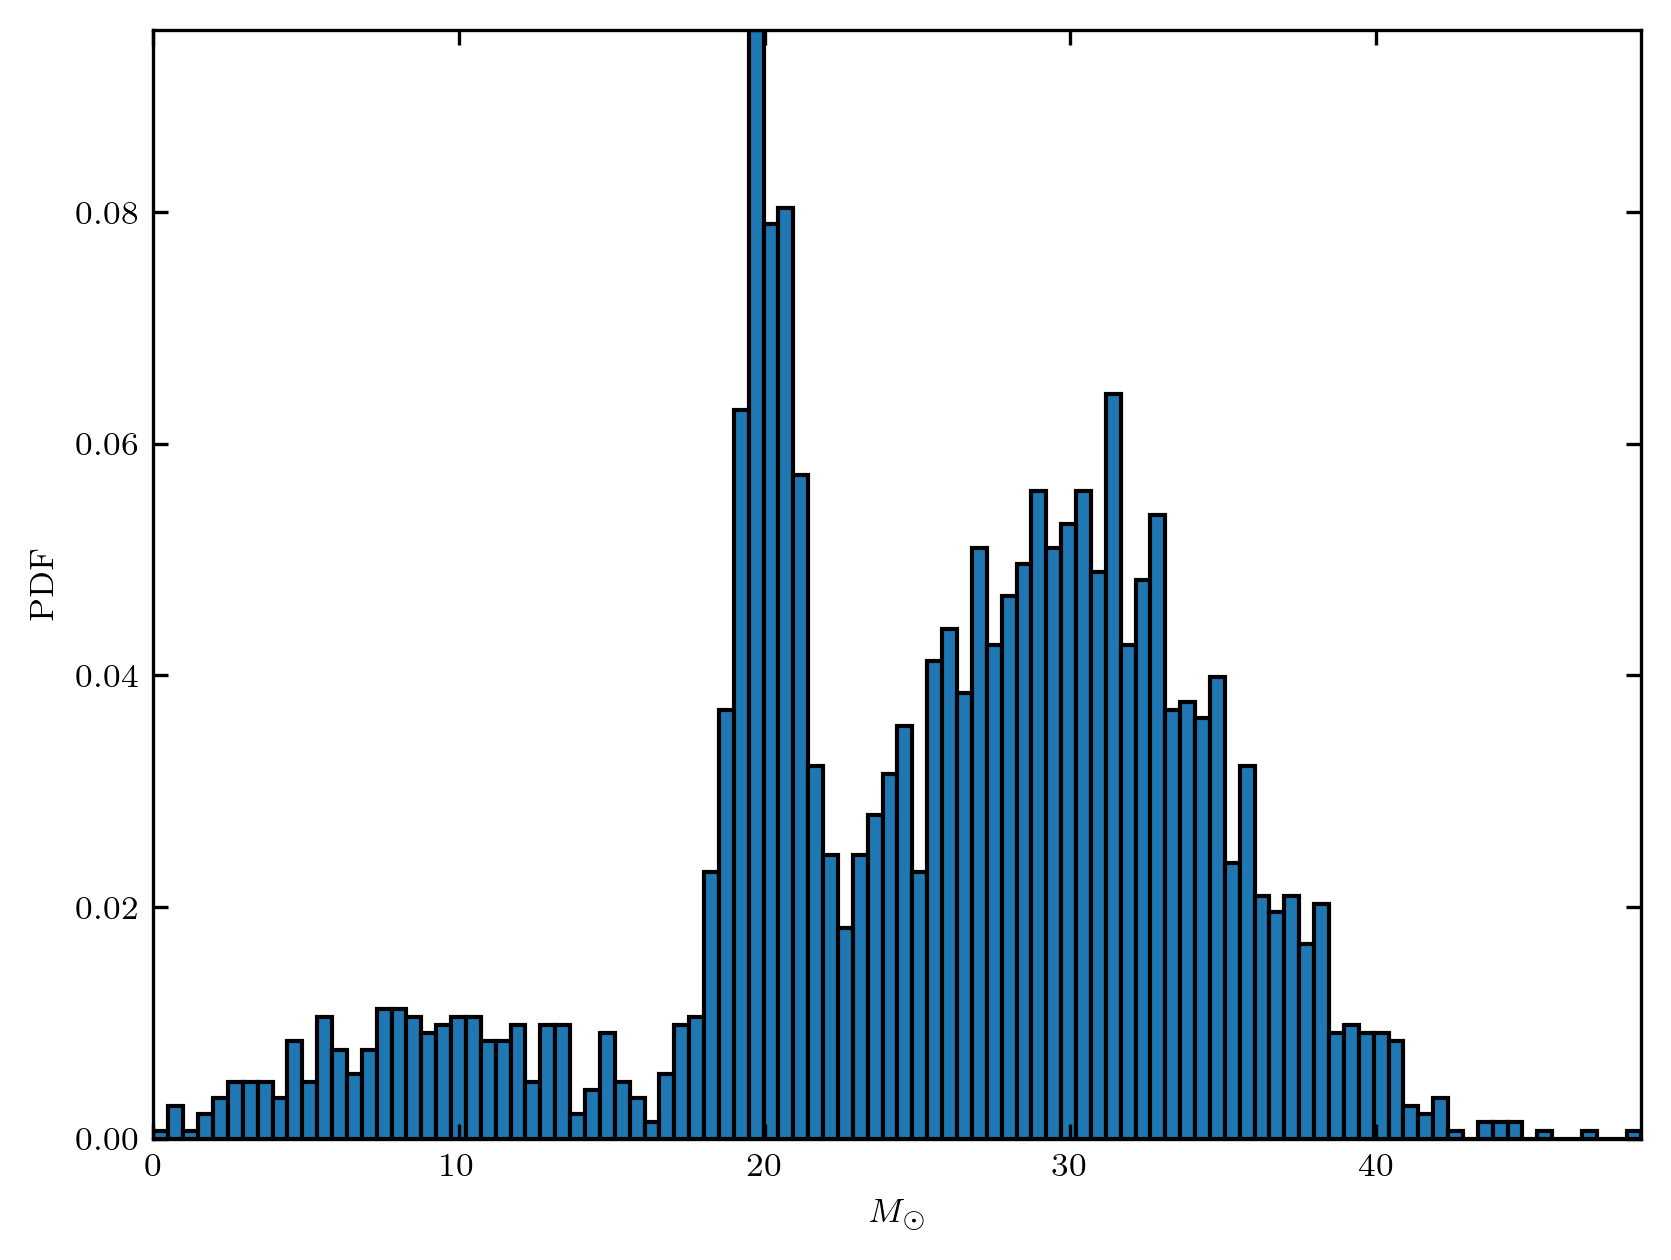

In [37]:
data = np.load('formationchannels.npy')
x_grid = np.linspace(data.min(),data.max(),100)

counts, bins, _ = plt.hist(data,bins = bin_counts, range=(0,data.max()), density = True)
plt.xlabel('$M_\odot$')
plt.ylabel('PDF')

There seems to be 3 main components. Let's define the Gaussian Mixture model to check: compute the AIC score, the PDF of the overall Gaussian Mixture and the weight that each component has.

In [38]:
GM =  []  
for ic in range(1,N_components+1):
    GM.append(GaussianMixture(ic))

fitGM = [None] * N_components
AIC = [None] * N_components
PDF = []
Responsabilities = []
for ic in range(N_components):
    fitGM[ic]=GM[ic].fit(data)
    AIC[ic]=fitGM[ic].aic(data)
    PDF.append(np.exp(fitGM[ic].score_samples(x_grid.reshape(-1,1))))
    Responsabilities.append(fitGM[ic].predict_proba(x_grid.reshape(-1,1)))

Plot the AIC vs N to check the model with the lowest score.

The number of components is: 3


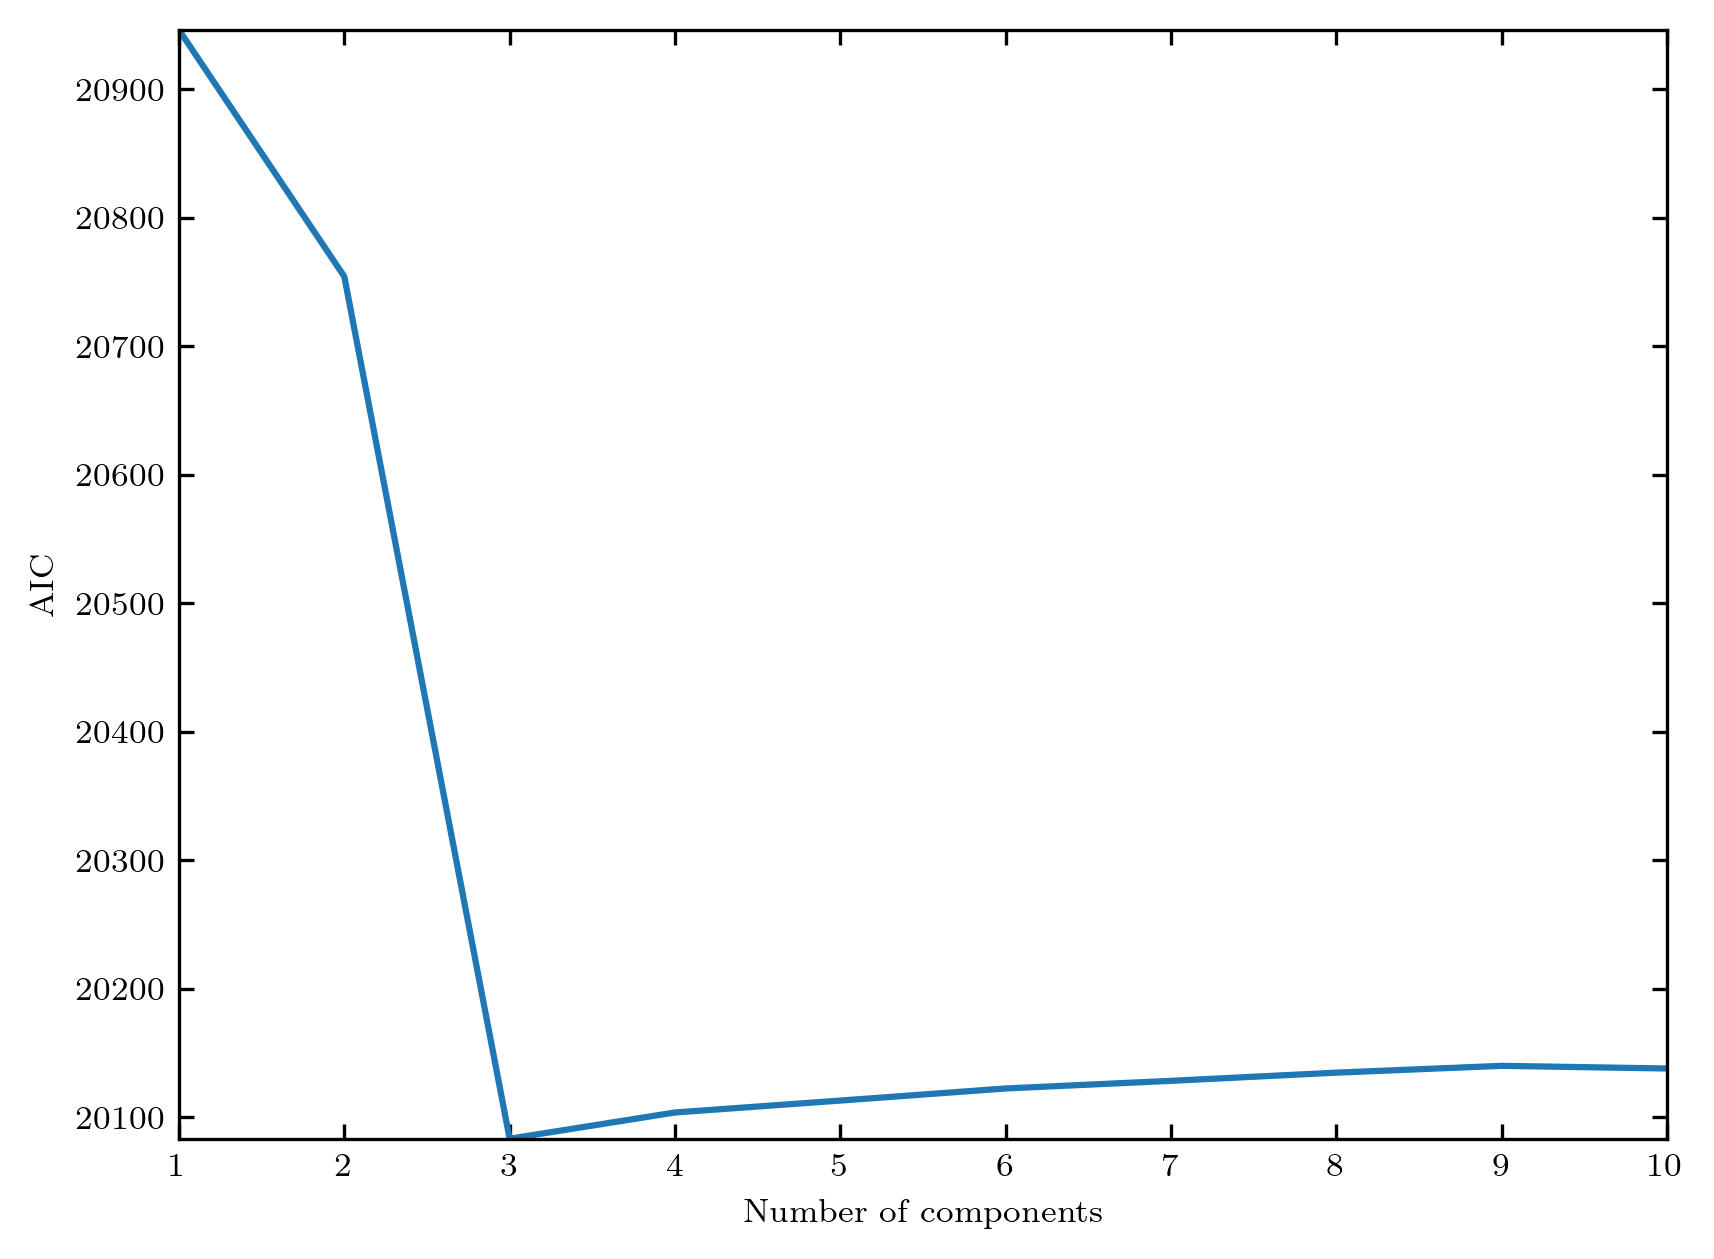

In [39]:
plt.figure()
plt.plot(list(range(1,N_components+1)),AIC)
plt.xlabel('Number of components')
plt.ylabel('AIC')
bestAIC_index = np.argmin(AIC)
N_comp = bestAIC_index+1
print(f'The number of components is: {N_comp}')

Compute the distribution of each component with two methods that provide the same result

In [40]:
mu = fitGM[bestAIC_index].means_
cov = fitGM[bestAIC_index].covariances_
weights = fitGM[bestAIC_index].weights_

pdf_individual = np.zeros((x_grid.size,N_comp))

for i in range(N_comp):
    mean = mu[i]
    std_dev = np.sqrt(cov[i])
    pdf_individual[:, i] = weights[i] * multivariate_normal.pdf(x_grid, mean=mean, cov=std_dev**2)
    # mean = mu[i,0]
    # std_dev = np.sqrt(cov[i,0,0])
    # pdf_individual[:, i] = weights[i] * norm.pdf(x_grid, loc=mean, scale=std_dev)

pdf_individual2 = Responsabilities[bestAIC_index] * PDF[bestAIC_index][:,np.newaxis]
print('The average distance between curves is: ', np.mean(np.linalg.norm(pdf_individual.flatten()-pdf_individual2.flatten())))

The average distance between curves is:  1.603044928980509e-16


Plot the fitted best Total Gaussian Mixture and each component. The Total mixture well overlaps with data

Text(0, 0.5, 'PDF')

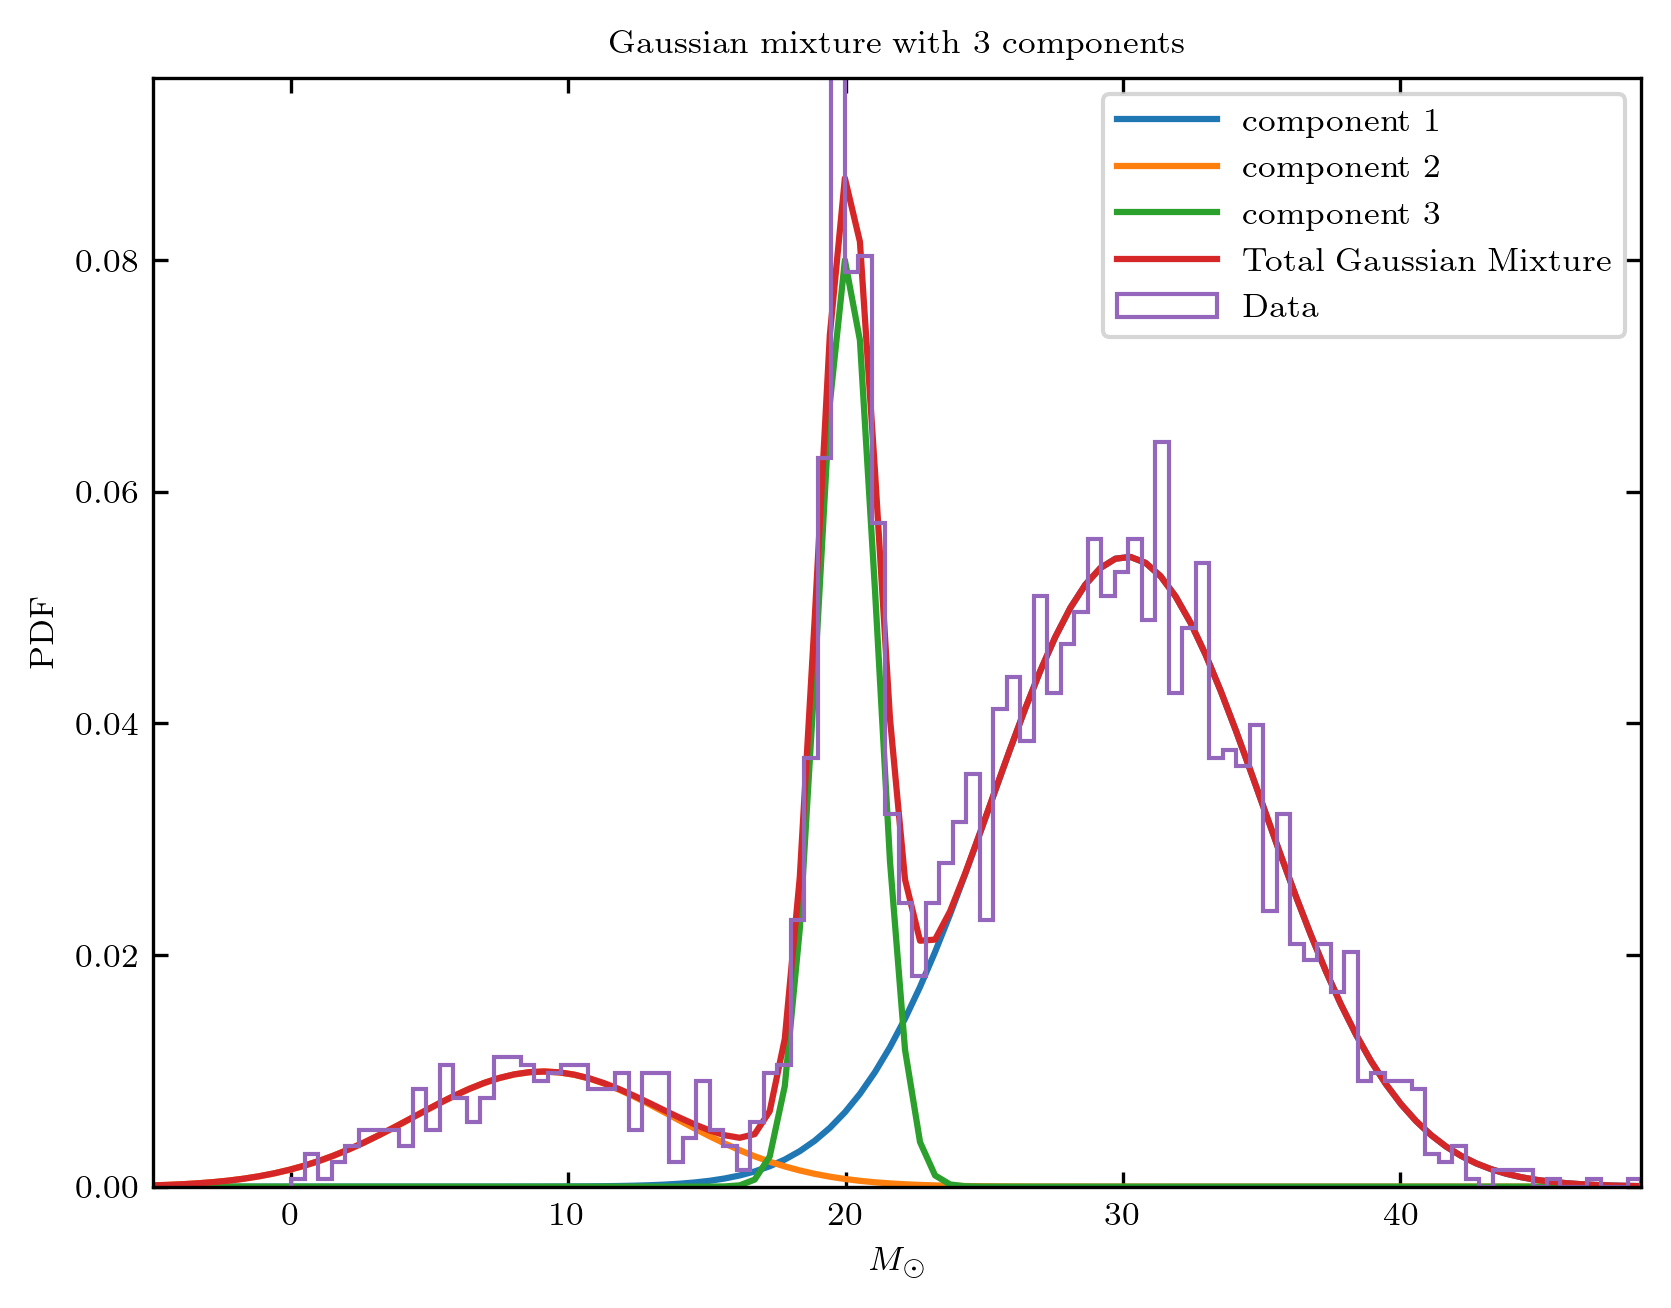

In [41]:
plt.figure()
lh = plt.plot(x_grid,pdf_individual,label=[f'component {n+1}' for n in range(N_comp)])
plt.plot(x_grid,PDF[bestAIC_index],label='Total Gaussian Mixture')
plt.hist(data,bins = bin_counts, range=(0,data.max()), density = True,label='Data',histtype='step')
plt.legend()
plt.title(f'Gaussian mixture with {N_comp} components')
plt.xlabel('$M_\odot$')
plt.ylabel('PDF')

To better show the contribution of each component to the total mixture, it's useful to plot the responabilities

Text(0, 0.5, 'Probability')

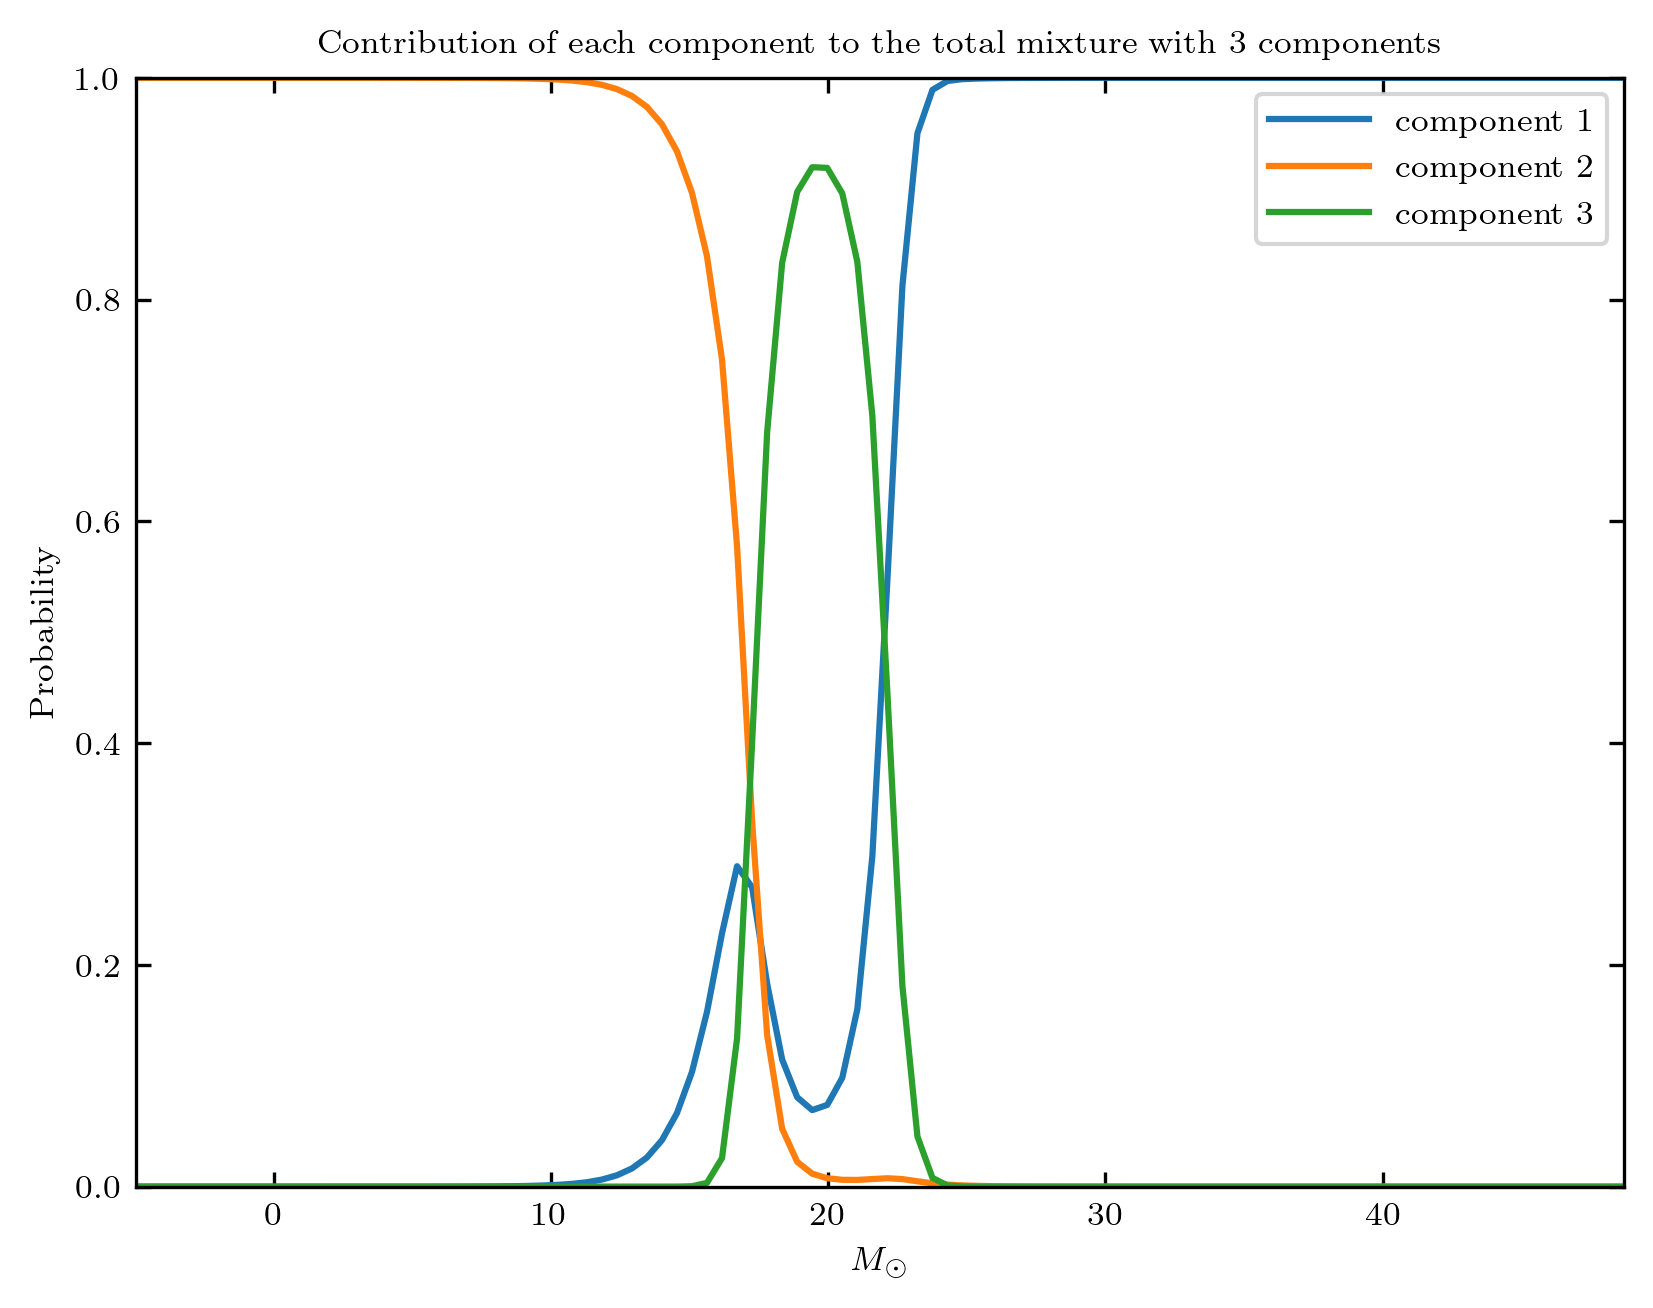

In [42]:
plt.figure()
colors = [line.get_color() for line in lh]
for il in range(N_comp):
    plt.plot(x_grid,Responsabilities[bestAIC_index][:,il],color = colors[il],label = f'component {il+1}')
plt.legend()
plt.title(f'Contribution of each component to the total mixture with {N_comp} components')
plt.xlabel('$M_\odot$')
plt.ylabel('Probability')
